# Görev 2: Gizli Formülü Bul (Training Loop)

Bu görevde amacımız PyTorch'un aslında nasıl "öğrendiğini" (forward pass, backward pass,
parametre güncelleme) kendi gözümüzle görmek. Hazır bir veri seti indirmedik, kendi sahte
verimizi kendimiz ürettik: `Y = 3*X + 2` formülüne biraz gürültü (noise) ekledik, sonra
modele bu formülü hiç söylemeden, sadece elindeki X-Y çiftlerine bakarak kendi kendine
bulup bulamayacağını denedik.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)  # her çalıştırdığımızda aynı sonucu görelim diye sabitledik

X = torch.randn(100, 1)
Y = 3 * X + 2 + torch.randn(100, 1) * 0.1

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: torch.Size([100, 1])
Y shape: torch.Size([100, 1])


## Model, loss ve optimizer

Tek katmanlı, basit bir model kullandık (`nn.Linear(1,1)`). Bunu öyle seçtik çünkü zaten
aradığımız formül de düz bir doğru denklemi (`y = w*x + b`) - karmaşık bir mimariye gerek
yok. Kayıp fonksiyonu olarak `MSELoss`, optimizasyon için de `SGD` kullandık, ikisi de bu
tarz basit regresyon işlerinde en klasik tercih olduğu için onları seçtik.

In [2]:
model = nn.Linear(1, 1)
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

# eğitim başlamadan önce modelin ne tahmin ettiğine bakalım, sona kıyaslamak için lazım olacak
with torch.no_grad():
    y_pred_before = model(X)

print("Eğitim öncesi weight:", model.weight.item())
print("Eğitim öncesi bias:", model.bias.item())

Eğitim öncesi weight: 0.48010575771331787
Eğitim öncesi bias: 0.8415044546127319


## Eğitim döngüsü (training loop)

Burada her adımda aynı 3 şeyi sırayla yapıyoruz, bunu neden böyle yaptığımızı da kısaca
anlatalım:

1. `optimizer.zero_grad()` - PyTorch gradyanları biriktire biriktire tutuyor, yani bir
   önceki adımdan kalanları silmezsek üst üste binip yanlış hesaba yol açar. O yüzden her
   turda önce sıfırlıyoruz.
2. `loss.backward()` - kayıp (loss) değerinden geriye doğru türev alıp weight ve bias'ın
   ne kadar "suçlu" olduğunu, yani gradyanlarını hesaplıyor.
3. `optimizer.step()` - optimizer bu gradyanlara bakıp weight ve bias'ı biraz güncelliyor,
   yani model küçük bir adım daha doğru yöne kaymış oluyor.

Bunu 1000 kere üst üste tekrarladık.

In [3]:
for epoch in range(1000):
    optimizer.zero_grad()
    y_pred = model(X)
    loss = criterion(y_pred, Y)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"epoch {epoch+1}, loss: {loss.item():.4f}")

epoch 100, loss: 0.0078
epoch 200, loss: 0.0078
epoch 300, loss: 0.0078
epoch 400, loss: 0.0078
epoch 500, loss: 0.0078
epoch 600, loss: 0.0078
epoch 700, loss: 0.0078
epoch 800, loss: 0.0078
epoch 900, loss: 0.0078
epoch 1000, loss: 0.0078


In [4]:
print("Öğrenilen weight:", model.weight.item())
print("Öğrenilen bias:", model.bias.item())
print("(gerçek formül: weight=3, bias=2 idi)")

Öğrenilen weight: 3.001180410385132
Öğrenilen bias: 2.003567934036255
(gerçek formül: weight=3, bias=2 idi)


**Model nasıl öğrendi?** Model hiçbir zaman "3" ve "2" sayılarını doğrudan görmedi, sadece
elindeki X-Y çiftlerine bakarak gizli formüle (weight ~3, bias ~2) kendi kendine çok
yaklaştı. Loss'un daha epoch 100'de 0.0078'e düşüp sonrasında pek değişmemesi de aslında
modelin veriye çok erken uyduğunu (yani "converge" olduğunu) gösteriyor - çünkü elimizdeki
veri basit ve doğrusal olduğu için modelin öğrenecek fazla bir şeyi yoktu, çabuk bitirdi işi.

## Eğitim öncesi vs sonrası görselleştirme

Burada `torch.no_grad()` kullandık, çünkü artık sadece tahmin alıp grafik çizeceğiz, gradyan
hesaplamaya hiç ihtiyacımız yok - kapatınca hem daha hızlı çalışıyor hem de boşuna bellek
harcanmamış oluyor.

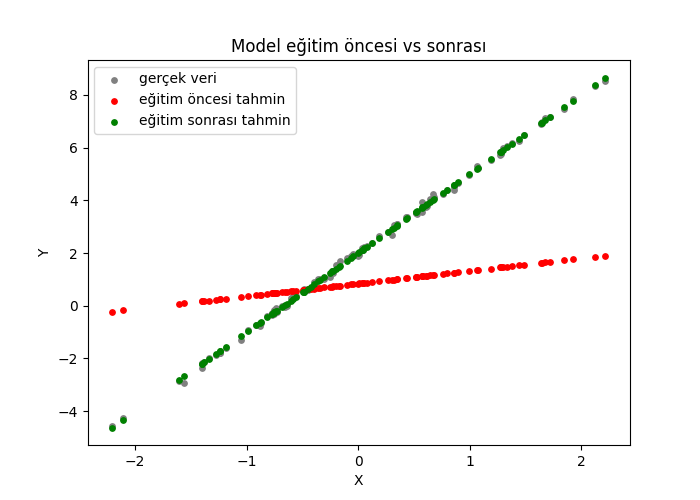

In [5]:
with torch.no_grad():
    y_pred_after = model(X)

plt.figure(figsize=(7, 5))
plt.scatter(X.numpy(), Y.numpy(), label="gerçek veri", color="gray", s=15)
plt.scatter(X.numpy(), y_pred_before.numpy(), label="eğitim öncesi tahmin", color="red", s=15)
plt.scatter(X.numpy(), y_pred_after.numpy(), label="eğitim sonrası tahmin", color="green", s=15)
plt.legend()
plt.title("Model eğitim öncesi vs sonrası")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()